<a href="https://colab.research.google.com/github/Anuska111/Breast-Cancer-Detection/blob/main/Breast_Cancer_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [116]:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [117]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [118]:
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [119]:
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [120]:
data_frame['label'] = breast_cancer_dataset.target

In [121]:
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [122]:
data_frame.shape

(569, 31)

In [123]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [124]:
data_frame.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [125]:
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [126]:
data_frame['label'].value_counts()

,count
label,
1,357
0,212


In [127]:
data_frame.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [128]:
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

In [129]:
print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [130]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int64


In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [132]:
print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [133]:
from sklearn.preprocessing import StandardScaler

In [134]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_std = scaler.transform(X_test)

In [135]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [136]:

model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(30,)),
                          keras.layers.Dense(20, activation='relu'),
                          keras.layers.Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [137]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [138]:
history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5770 - loss: 0.7613 - val_accuracy: 0.6304 - val_loss: 0.6976
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7677 - loss: 0.5292 - val_accuracy: 0.8478 - val_loss: 0.4773
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8631 - loss: 0.3822 - val_accuracy: 0.9130 - val_loss: 0.3426
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9193 - loss: 0.2931 - val_accuracy: 0.9348 - val_loss: 0.2641
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9413 - loss: 0.2390 - val_accuracy: 0.9348 - val_loss: 0.2179
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.2036 - val_accuracy: 0.9348 - val_loss: 0.1884
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1784 - val_accuracy: 0.9348 - val_loss: 0.1680
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9633 - loss: 0.1591 - val_accuracy: 0.9348 - val_loss

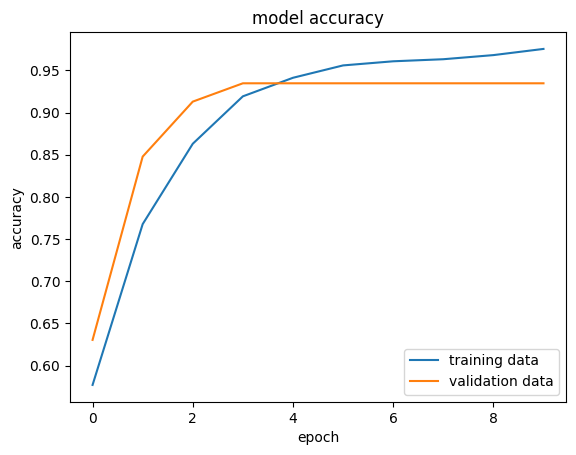

In [139]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

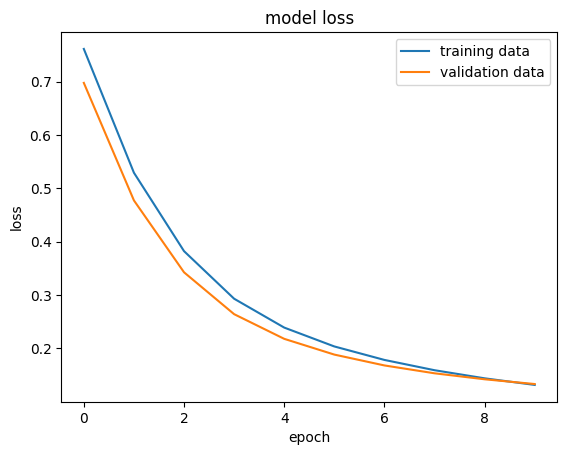

In [140]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'upper right')

In [141]:
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9386 - loss: 0.1340
0.9385964870452881


In [142]:
print(X_test_std.shape)
print(X_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [143]:
Y_pred = model.predict(X_test_std)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [144]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.40027863 0.8366368 ]


In [145]:
print(X_test_std)

[[-0.04462793 -1.41612656 -0.05903514 ... -0.18278004 -1.23064515
  -0.6268286 ]
 [ 0.24583601 -0.06219797  0.21802678 ...  0.54129749  0.11047691
   0.0483572 ]
 [-1.26115925 -0.29051645 -1.26499659 ... -1.35138617  0.269338
  -0.28231213]
 ...
 [ 0.72709489  0.45836817  0.75277276 ...  1.46701686  1.19909344
   0.65319961]
 [ 0.25437907  1.33054477  0.15659489 ... -1.29043534 -2.22561725
  -1.59557344]
 [ 0.84100232 -0.06676434  0.8929529  ...  2.15137705  0.35629355
   0.37459546]]


In [146]:
print(Y_pred)

[[0.40027863 0.8366368 ]
 [0.5648094  0.6473525 ]
 [0.15991132 0.97707516]
 [0.98836404 0.0339994 ]
 [0.5589515  0.6476623 ]
 [0.9842823  0.17181952]
 [0.38117504 0.78287274]
 [0.1268184  0.9554297 ]
 [0.2787129  0.9234237 ]
 [0.3425343  0.942642  ]
 [0.6223782  0.6477675 ]
 [0.44075906 0.906598  ]
 [0.45344794 0.9381644 ]
 [0.33055842 0.88099396]
 [0.30042168 0.9573479 ]
 [0.9218557  0.41302764]
 [0.22269763 0.9636643 ]
 [0.1803779  0.95592916]
 [0.38079107 0.9676072 ]
 [0.956865   0.13221745]
 [0.07147781 0.19220918]
 [0.18789959 0.9291128 ]
 [0.18689938 0.8967527 ]
 [0.23649345 0.9814064 ]
 [0.40865505 0.86615974]
 [0.89097303 0.26152933]
 [0.2441095  0.7847853 ]
 [0.37570545 0.54675716]
 [0.8729619  0.2946988 ]
 [0.9411191  0.3631621 ]
 [0.45489645 0.8323987 ]
 [0.38614303 0.9538105 ]
 [0.2838027  0.9426983 ]
 [0.99821603 0.12524115]
 [0.92072856 0.18972023]
 [0.36189947 0.7912459 ]
 [0.09872509 0.89964014]
 [0.34218785 0.7499814 ]
 [0.10757184 0.9749676 ]
 [0.29383236 0.9642219 ]


In [147]:
#  argmax function

my_list = [0.25, 0.56]

index_of_max_value = np.argmax(my_list)
print(my_list)
print(index_of_max_value)

[0.25, 0.56]
1


In [148]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

In [149]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print(prediction)

prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
  print('The tumor is Malignant')

else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.17799945 0.91926813]]
[np.int64(1)]
The tumor is Benign


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [150]:
# Predictions
y_pred_prob = model.predict(X_test)

# Convert probabilities into 0/1 classes
y_pred = (y_pred_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


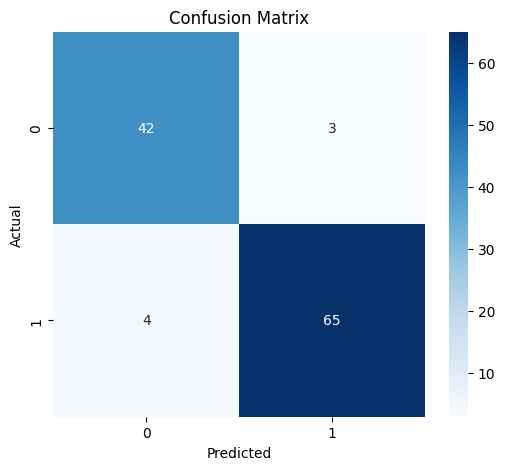

In [151]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [152]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_labels))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        45
           1       0.96      0.94      0.95        69

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



In [153]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(Y_test, Y_pred[:, 1])

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9745571658615136


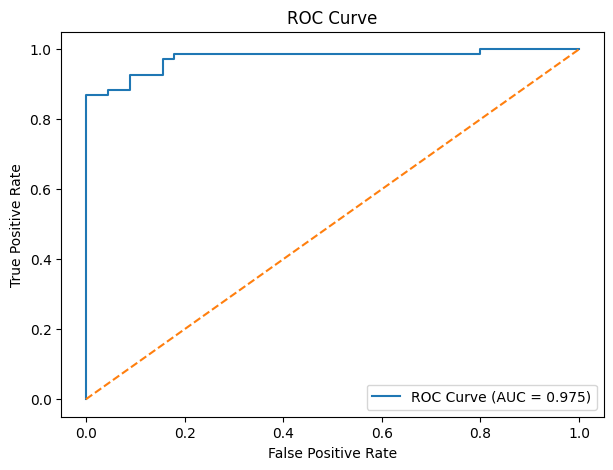

In [154]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred[:, 1])

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [155]:
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())
print("Mean:", X_train.mean())
print("Standard Deviation:", X_train.std())

Minimum: mean radius                  6.981000
mean texture                 9.710000
mean perimeter              43.790000
mean area                  143.500000
mean smoothness              0.052630
mean compactness             0.023440
mean concavity               0.000000
mean concave points          0.000000
mean symmetry                0.116700
mean fractal dimension       0.049960
radius error                 0.111500
texture error                0.360200
perimeter error              0.757000
area error                   6.802000
smoothness error             0.001713
compactness error            0.003012
concavity error              0.000000
concave points error         0.000000
symmetry error               0.009947
fractal dimension error      0.000895
worst radius                 7.930000
worst texture               12.020000
worst perimeter             50.410000
worst area                 185.200000
worst smoothness             0.071170
worst compactness            0.027290
wor

In [156]:
print("First 5 rows of X_train:")
print(X_train[:5])

First 5 rows of X_train:
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
560        14.05         27.15           91.38      600.4          0.09929   
428        11.13         16.62           70.47      381.1          0.08151   
198        19.18         22.49          127.50     1148.0          0.08523   
203        13.81         23.75           91.56      597.8          0.13230   
41         10.95         21.35           71.90      371.1          0.12270   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
560           0.11260         0.04462              0.04304         0.1537   
428           0.03834         0.01369              0.01370         0.1511   
198           0.14280         0.11140              0.06772         0.1767   
203           0.17680         0.15580              0.09176         0.2251   
41            0.12180         0.10440              0.05669         0.1895   

     mean fractal dimension  ...  worst rad

In [157]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train:")
print(X_train_scaled[:5])

Scaled X_train:
[[-0.01330339  1.7757658  -0.01491962 -0.14478895  0.22879041  0.17546662
  -0.54440164 -0.1282563  -1.01205427 -0.15270564 -0.11809273  0.51565734
   0.03524556 -0.2057197   0.09043522  0.08775907 -0.39162479  0.79264996
   0.03869712  0.64948729 -0.18639977  1.18721279 -0.19614077 -0.2913543
  -0.33218215 -0.17136714 -0.65932952 -0.13236958 -1.08014517 -0.03527943]
 [-0.8448276  -0.6284278  -0.87702746 -0.76561031 -1.01982093 -1.24905895
  -0.94455384 -0.88909098 -1.109505   -0.18616526 -0.91650146 -0.45422866
  -0.90363301 -0.637863   -0.36428848 -1.07873087 -0.82448558 -0.92858668
  -0.04989848 -0.56863123 -0.94999203 -0.88456941 -0.98076453 -0.80649673
  -1.24062985 -1.22454081 -1.07819957 -1.11552632 -0.85773964 -0.72098905]
 [ 1.44755936  0.71180168  1.47428816  1.40542437 -0.75858166  0.75479159
   0.31955452  0.51173688 -0.1499901  -1.08666527  0.13682522 -0.25855153
   0.49734986  0.31750506 -0.48318564  0.66767804 -0.14863805  0.10046365
  -0.7911067  -0.1441

In [158]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_dropout = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(8, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_dropout.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_dropout = model_dropout.fit(
    X_train_scaled,
    Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6264 - loss: 0.9220 - val_accuracy: 0.6264 - val_loss: 0.7362
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6429 - loss: 0.7317 - val_accuracy: 0.6264 - val_loss: 0.6215
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6236 - loss: 0.6454 - val_accuracy: 0.6264 - val_loss: 0.5372
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6593 - loss: 0.5612 - val_accuracy: 0.6484 - val_loss: 0.4782
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6593 - loss: 0.5276 - val_accuracy: 0.6923 - val_loss: 0.4422
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6923 - loss: 0.5066 - val_accuracy: 0.7363 - val_loss: 0.4162
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7115 - loss: 0.4591 - val_accuracy: 0.7912 - val_loss: 0.3956
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7637 - loss: 0.4553 - val_accuracy: 0.83

In [160]:
test_loss, test_accuracy = model_dropout.evaluate(
    X_test_scaled,
    Y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.11653164029121399
Test Accuracy: 0.9561403393745422


In [161]:
from sklearn.metrics import classification_report

y_dropout_prob = model_dropout.predict(X_test_scaled)
y_dropout_pred = (y_dropout_prob > 0.5).astype(int)

print(classification_report(Y_test, y_dropout_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        45
           1       0.97      0.96      0.96        69

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [162]:
from sklearn.metrics import roc_auc_score

dropout_roc_auc = roc_auc_score(Y_test, y_dropout_prob)

print("Dropout ROC-AUC:", dropout_roc_auc)

Dropout ROC-AUC: 0.9929146537842191


In [163]:
model_dropout.save("breast_cancer_model.keras")

In [164]:
# 1D CNN requires 3D input: (batch_size, num_features, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)

X_train_cnn shape: (455, 30, 1)
X_test_cnn shape: (114, 30, 1)


In [165]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Flatten, Dense, Dropout

cnn_model = Sequential([
    # First Convolutional Block
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(30, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Second Convolutional Block
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Flatten and Fully Connected Layers
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 29, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 13, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,153 (113.88 KB)

 Non-trainable params: 192 (768.00 B)

In [166]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    X_train_cnn,
    Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7802 - loss: 0.5401 - val_accuracy: 0.9341 - val_loss: 0.5517
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9148 - loss: 0.1910 - val_accuracy: 0.9451 - val_loss: 0.5032
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9203 - loss: 0.1779 - val_accuracy: 0.9560 - val_loss: 0.4726
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9505 - loss: 0.1153 - val_accuracy: 0.9451 - val_loss: 0.4399
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9643 - loss: 0.1082 - val_accuracy: 0.9451 - val_loss: 0.4172
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9753 - loss: 0.0781 - val_accuracy: 0.9560 - val_loss: 0.3977
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9753 - loss: 0.0717 - val_accuracy: 0.9560 - val_loss: 0.3789
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9643 - loss: 0.0884 - val_accuracy: 0.

CNN Test Loss: 0.1572
CNN Test Accuracy: 0.9649


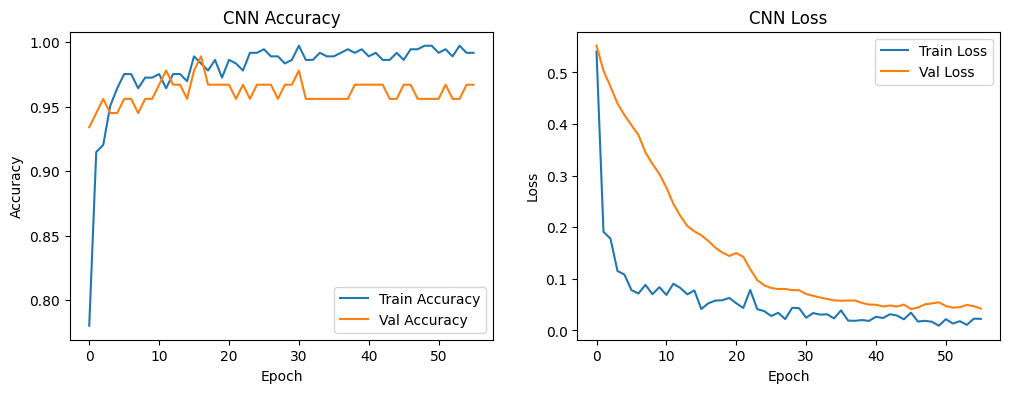

In [167]:
import matplotlib.pyplot as plt

# Evaluation
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test_cnn, Y_test, verbose=0)
print(f"CNN Test Loss: {test_loss_cnn:.4f}")
print(f"CNN Test Accuracy: {test_acc_cnn:.4f}")

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        45
           1       0.97      0.97      0.97        69

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

CNN ROC-AUC Score: 0.991304347826087


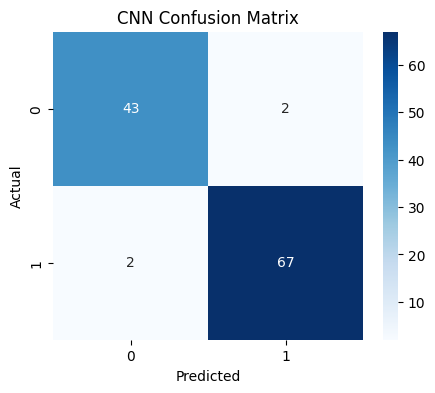

In [168]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Predictions
y_cnn_prob = cnn_model.predict(X_test_cnn)
y_cnn_pred = (y_cnn_prob > 0.5).astype(int)

# Classification Report & ROC-AUC
print(classification_report(Y_test, y_cnn_pred))
print("CNN ROC-AUC Score:", roc_auc_score(Y_test, y_cnn_prob))

# Confusion Matrix
cm_cnn = confusion_matrix(Y_test, y_cnn_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

CNN ROC-AUC Score: 0.9913


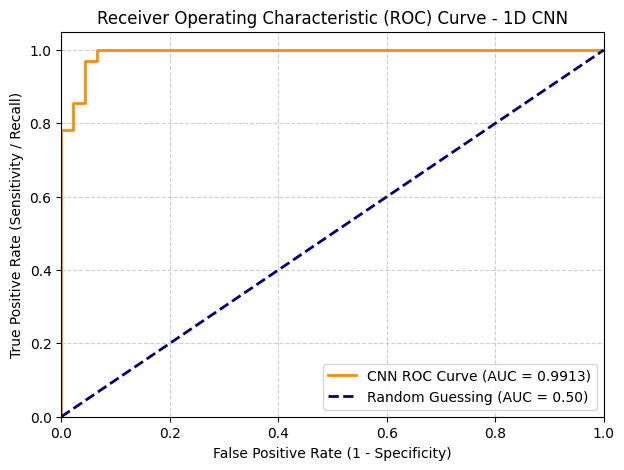

In [169]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC-AUC Score
cnn_roc_auc = roc_auc_score(Y_test, y_cnn_prob)
print(f"CNN ROC-AUC Score: {cnn_roc_auc:.4f}")

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr_cnn, tpr_cnn, thresholds = roc_curve(Y_test, y_cnn_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_cnn, tpr_cnn, color='darkorange', lw=2, label=f'CNN ROC Curve (AUC = {cnn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - 1D CNN')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [181]:

requirements_content = """streamlit==1.41.1
tflite-runtime==2.14.0
numpy==1.26.4
Pillow==11.0.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt successfully created!")

# Download from Google Colab
from google.colab import files

files.download("requirements.txt")

✅ requirements.txt successfully created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [182]:
import os

# 1. 1D-CNN model ko save karein
cnn_model.save("breast_cancer_cnn_model.keras")

# 2. Files ka size calculate karke print karein
cnn_size_kb = os.path.getsize("breast_cancer_cnn_model.keras") / 1024
scaler_size_kb = os.path.getsize("scaler.pkl") / 1024

print("----------------------------------------")
print(f"📊 1D-CNN Model Size : {cnn_size_kb:.2f} KB")
print(f"📊 Scaler File Size  : {scaler_size_kb:.2f} KB")
print("----------------------------------------")

----------------------------------------
📊 1D-CNN Model Size : 397.25 KB
📊 Scaler File Size  : 2.08 KB
----------------------------------------


In [183]:
import os

files = [
    "/content/tumor_cnn.keras",
    "/content/dataset.zip",
    "/content/breast_ultrasound.zip"
]

print("========== FILE SIZES ==========\n")

for file in files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"{os.path.basename(file)} : {size_mb:.2f} MB")
    else:
        print(f"❌ {os.path.basename(file)} : File not found")

========== FILE SIZES ==========

tumor_cnn.keras : 37.87 MB
dataset.zip : 194.95 MB
breast_ultrasound.zip : 194.95 MB


In [184]:
# ==========================================
# CNN MODEL COMPRESSION
# Float16 Quantization
# ==========================================

import tensorflow as tf
import os

model_path = "/content/tumor_cnn.keras"

# Load model
model = tf.keras.models.load_model(model_path)

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Float16 quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

# Save compressed model
compressed_path = "/content/tumor_cnn_float16.tflite"

with open(compressed_path, "wb") as f:
    f.write(tflite_model)

# Check size
size_mb = os.path.getsize(compressed_path) / (1024 * 1024)

print("================================")
print("Compressed CNN Model")
print("================================")
print(f"Original : 37.87 MB")
print(f"Compressed : {size_mb:.2f} MB")

if size_mb < 25:
    print("✅ UNDER 25 MB")
else:
    print("⚠️ Still above 25 MB")

Saved artifact at '/tmp/tmpvtgyeuaf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140348223794128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348234149584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348234147856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235417552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235417936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235424656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235430032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235425424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235425040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348235428688: TensorSpec(shape=(), dtype=tf.resource, name=None)
Compressed CNN 